### librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

### data

In [42]:
DATA_PREDICTIONS_PATH = "data\\predictions_1993-2025_1_ano_10p_rol.csv"

def load_csv(path):
    return pd.read_csv(path)

In [43]:
df_predictions = load_csv(DATA_PREDICTIONS_PATH)[["date", "pred_cop_usd", "true_cop_usd", "error_abs"]]

# 1. Asegurar formato fecha
df_predictions["date"] = pd.to_datetime(df_predictions["date"])

# 2. Ordenar cronológicamente (esto evita las líneas cruzadas en los plots)
df_predictions = df_predictions.sort_values("date").reset_index(drop=True)

# 3. Calcular el error
df_predictions["error"] = df_predictions["pred_cop_usd"] - df_predictions["true_cop_usd"]

df_predictions.head(10)

,date,pred_cop_usd,true_cop_usd,error_abs,error
0,2003-01-01,2853.695312,2867.000000,13.304688,-13.304688
1,2003-01-02,2851.714355,2838.000000,13.714355,13.714355
2,2003-01-03,2850.186035,2848.000000,2.186035,2.186035
3,2003-01-06,2837.713867,2851.000000,13.286133,-13.286133
4,2003-01-07,2853.701172,2907.000000,53.298828,-53.298828
5,2003-01-08,2858.394531,2893.000000,34.605469,-34.605469
6,2003-01-09,2872.360840,2900.500000,28.139160,-28.139160
7,2003-01-10,2888.957031,2909.500000,20.542969,-20.542969
8,2003-01-13,2874.313232,2904.449951,30.136719,-30.136719
9,2003-01-14,2869.079346,2905.449951,36.370605,-36.370605


### plot-time series

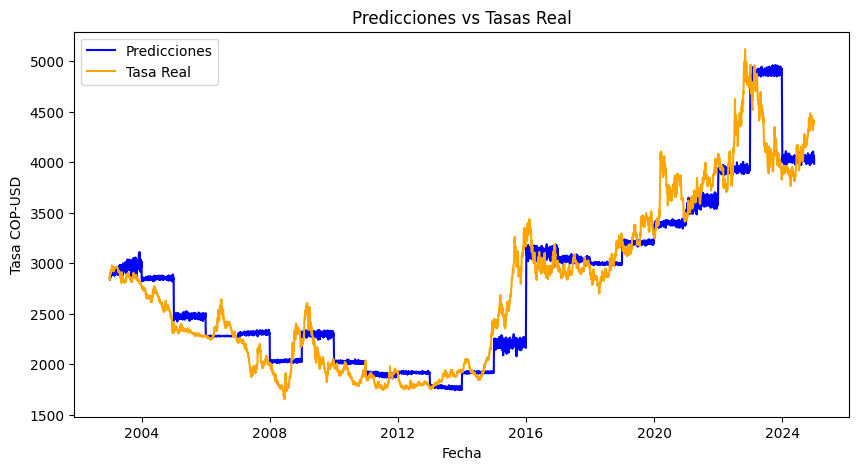

In [44]:
data_1994_2025 = df_predictions[df_predictions["date"] >= "1996-01-01"].copy()
plt.figure(figsize=(10, 5))
plt.plot(data_1994_2025["date"], data_1994_2025["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_1994_2025["date"], data_1994_2025["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

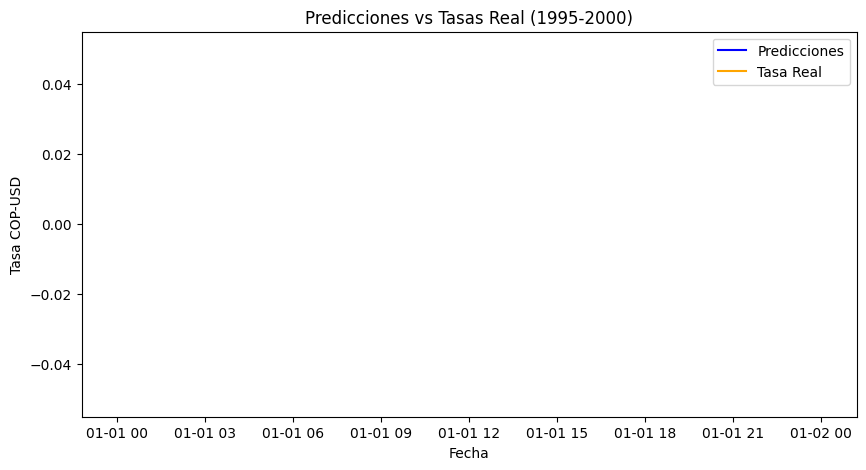

In [45]:
data_1995_2000 = df_predictions[(df_predictions["date"] >= "1995-01-01") & (df_predictions["date"] < "2001-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_1995_2000["date"], data_1995_2000["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_1995_2000["date"], data_1995_2000["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (1995-2000)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

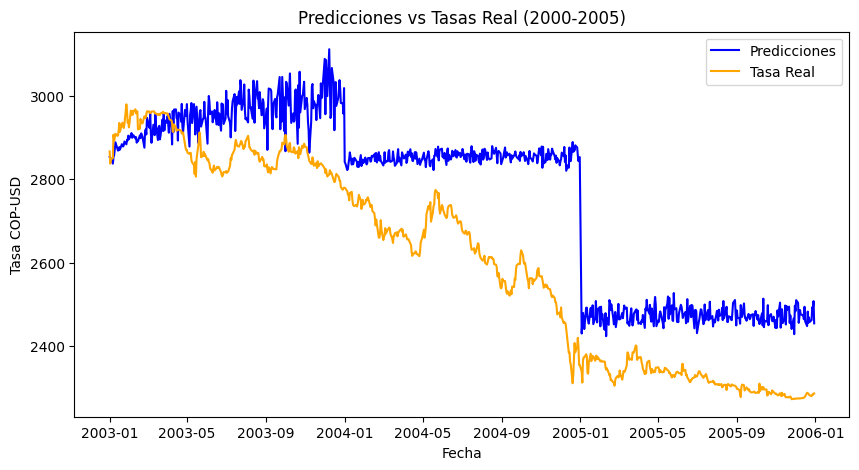

In [46]:
data_2000_2005 = df_predictions[(df_predictions["date"] >= "2000-01-01") & (df_predictions["date"] < "2006-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2000_2005["date"], data_2000_2005["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2000_2005["date"], data_2000_2005["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2000-2005)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

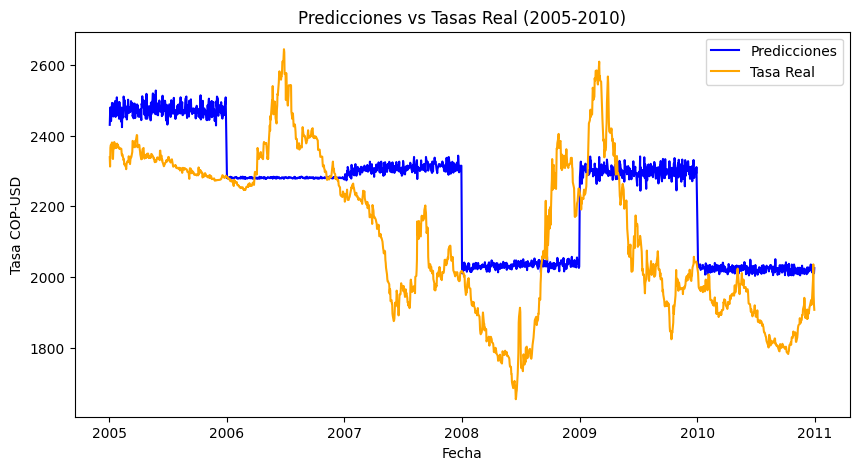

In [47]:
data_2005_2010 = df_predictions[(df_predictions["date"] >= "2005-01-01") & (df_predictions["date"] < "2011-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2005_2010["date"], data_2005_2010["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2005_2010["date"], data_2005_2010["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2005-2010)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

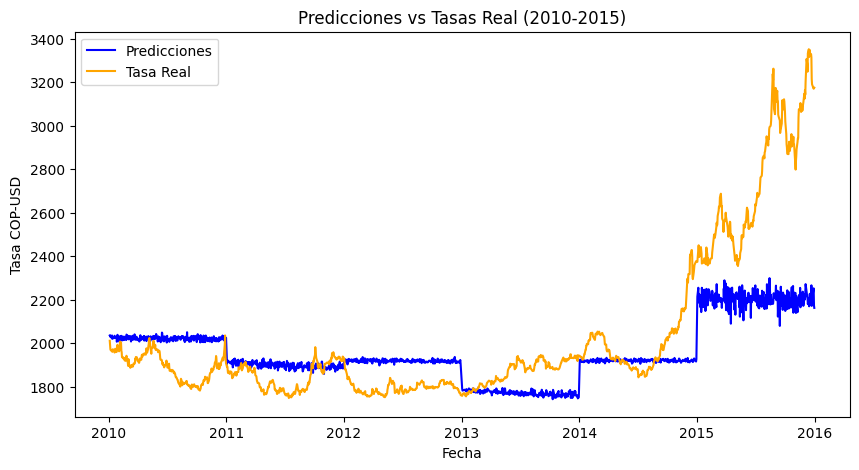

In [48]:
data_2010_2015 = df_predictions[(df_predictions["date"] >= "2010-01-01") & (df_predictions["date"] < "2016-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2010_2015["date"], data_2010_2015["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2010_2015["date"], data_2010_2015["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2010-2015)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

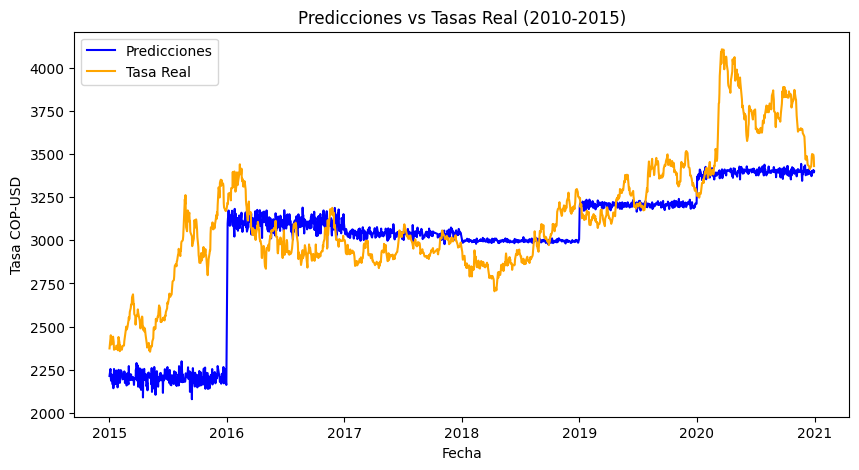

In [49]:
data_2015_2020 = df_predictions[(df_predictions["date"] >= "2015-01-01") & (df_predictions["date"] < "2021-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2015_2020["date"], data_2015_2020["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2015_2020["date"], data_2015_2020["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2010-2015)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

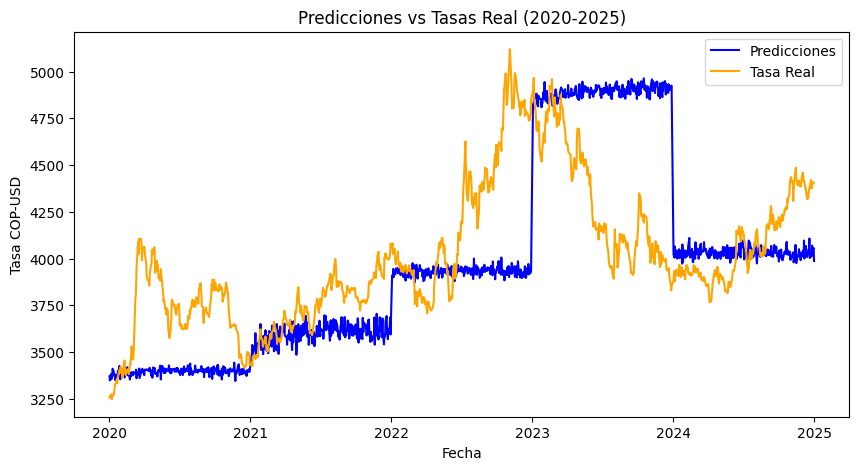

In [61]:
data_2020_2025 = df_predictions[(df_predictions["date"] >= "2020-01-01") & (df_predictions["date"] < "2026-01-01")]
plt.figure(figsize=(10, 5))
plt.plot(data_2020_2025["date"], data_2020_2025["pred_cop_usd"], label='Predicciones', color='blue')
plt.plot(data_2020_2025["date"], data_2020_2025["true_cop_usd"], label='Tasa Real', color='orange')

plt.title('Predicciones vs Tasas Real (2020-2025)')
plt.xlabel('Fecha')
plt.ylabel('Tasa COP-USD')
plt.legend()
plt.show()

### Error Analisis

#### Sobre o Sube Estimacion

In [51]:
mean_error = df_predictions["error"].mean()
dest_error = df_predictions["error"].std()
median_error = df_predictions["error"].median()

print(f"Mean error: {mean_error}")
print(f"Std Desv error: {dest_error}")
print(f"Median error: {median_error}")

# proporciones
over = np.mean(df_predictions["error"] > 0)
under = np.mean(df_predictions["error"] < 0)

print(f"Sobreestima: {over:.2%}")
print(f"Subestima: {under:.2%}")

Mean error: 11.917721283812545
Std Desv error: 281.08572759604846
Median error: 56.2364501953125
Sobreestima: 60.23%
Subestima: 39.77%


#### Distribucion del error:

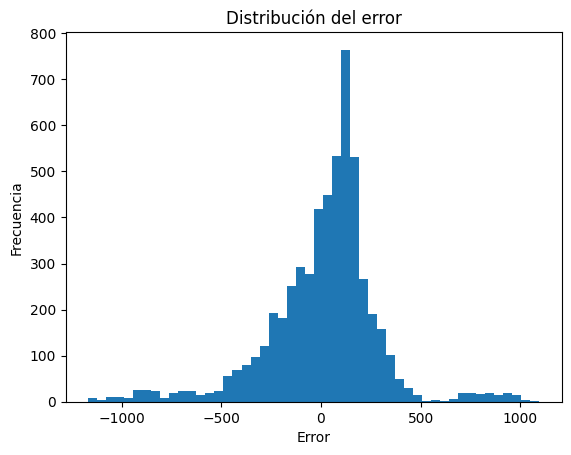

In [52]:
plt.figure()
plt.hist(df_predictions["error"], bins=50)
plt.title("Distribución del error")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

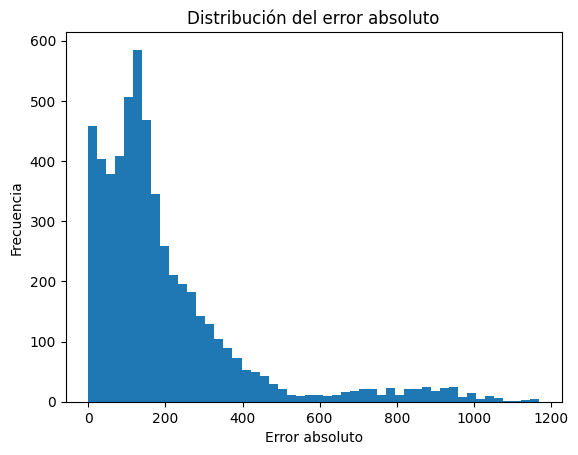

In [53]:
plt.figure()
plt.hist(df_predictions["error_abs"], bins=50)
plt.title("Distribución del error absoluto")
plt.xlabel("Error absoluto")
plt.ylabel("Frecuencia")
plt.show()

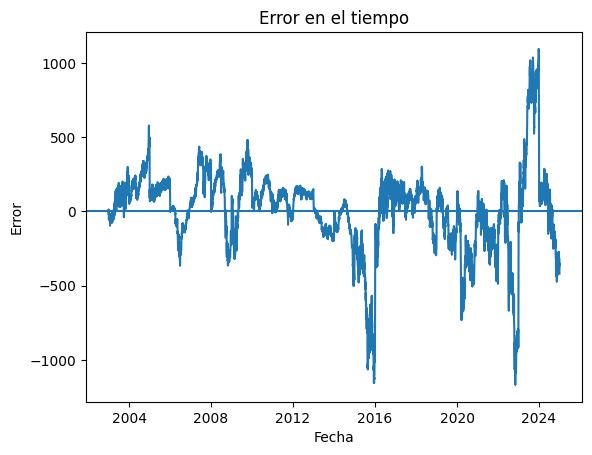

In [54]:
plt.figure()
plt.plot(df_predictions["date"], df_predictions["error"])
plt.axhline(0)
plt.title("Error en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Error")
plt.show()

In [55]:
errors = df_predictions["error"]

mean = errors.mean()
std = errors.std(ddof=1)
n = len(errors)

# intervalo de confianza del error medio
ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=std/np.sqrt(n))

print(f"IC 95% del error medio: {ci}")

# percentiles (más robusto que asumir normalidad)
p_low = np.percentile(errors, 2.5)
p_high = np.percentile(errors, 97.5)

print(f"Intervalo empírico 95% del error: [{p_low}, {p_high}]")

p_low_abs = np.percentile(df_predictions["error_abs"], 2.5)
p_high_abs = np.percentile(df_predictions["error_abs"], 97.5)

print(f"Intervalo empírico 95% del error absoluto: [{p_low_abs}, {p_high_abs}]")

IC 95% del error medio: (np.float64(4.491561680774573), np.float64(19.343880886850517))
Intervalo empírico 95% del error: [-726.6756896972656, 564.7273559570312]
Intervalo empírico 95% del error absoluto: [6.5882415771484375, 867.8169555664062]


#### plot Resampling:

In [56]:
df_predictions_time_series = df_predictions.set_index("date")

In [57]:
def analyze_errors(df, label=""):
    import numpy as np
    import matplotlib.pyplot as plt
    
    df = df.copy()
    
    df["error"] = df["pred_cop_usd"] - df["true_cop_usd"]
    df["error_abs"] = np.abs(df["error"])
    
    # 🔥 CLAVE: eliminar NaNs
    errors = df["error"].dropna()
    errors_abs = df["error_abs"].dropna()
    
    print(f"\n--- {label} ---")
    
    print("Mean error:", errors.mean())
    print("Std error:", errors.std())
    
    print("IC 95% error:",
          np.percentile(errors, [2.5, 97.5]))
    
    print("IC 95% error abs:",
          np.percentile(errors_abs, [2.5, 97.5]))
    
    # plots
    plt.figure()
    plt.hist(errors, bins=50)
    plt.title(f"Error distribution {label}")
    plt.show()
    
    plt.figure()
    plt.hist(errors_abs, bins=50)
    plt.title(f"Absolute error distribution {label}")
    plt.show()


--- Weekly ---
Mean error: 10.922271930548376
Std error: 281.5374887540859
IC 95% error: [-715.56848877  656.23297607]
IC 95% error abs: [  6.29961945 883.90065186]


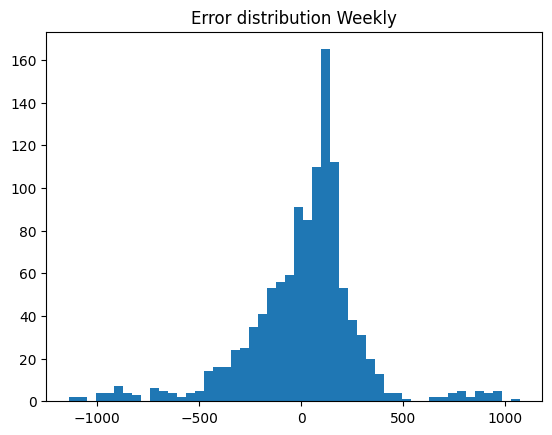

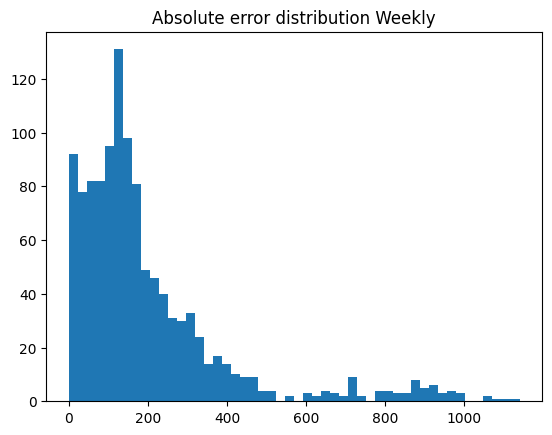

In [58]:
df_weekly = df_predictions_time_series.resample("W").mean()
analyze_errors(df_weekly, "Weekly")


--- Mothly ---
Mean error: 10.922271930548376
Std error: 281.5374887540859
IC 95% error: [-715.56848877  656.23297607]
IC 95% error abs: [  6.29961945 883.90065186]


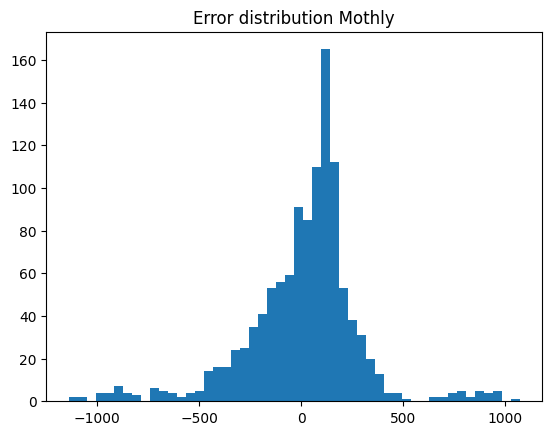

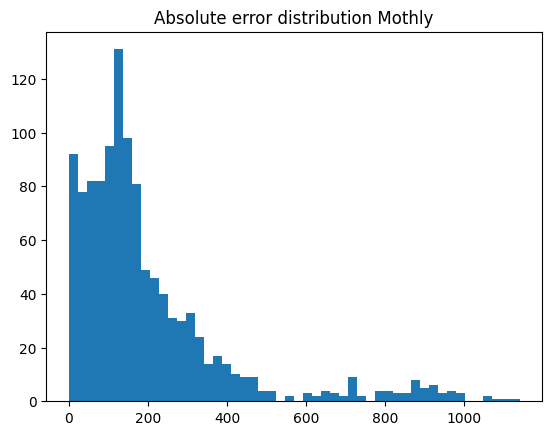

In [59]:
df_mothly = df_predictions_time_series.resample("ME").mean()
analyze_errors(df_weekly, "Mothly")


--- Yearly ---
Mean error: 10.922271930548376
Std error: 281.5374887540859
IC 95% error: [-715.56848877  656.23297607]
IC 95% error abs: [  6.29961945 883.90065186]


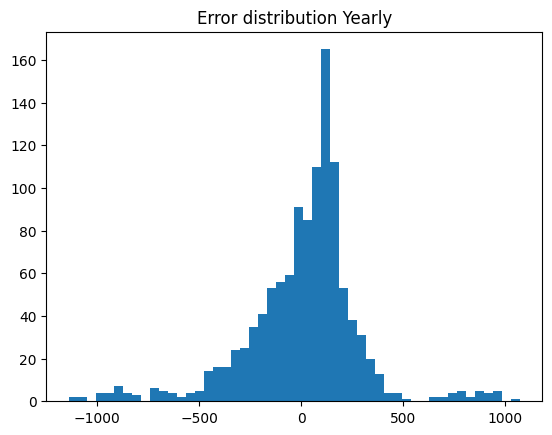

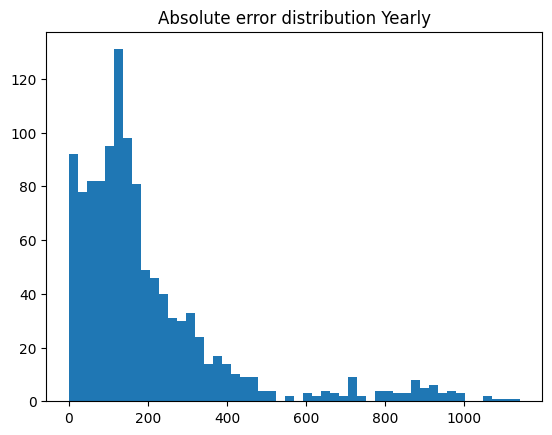

In [60]:
df_yearly = df_predictions_time_series.resample("YE").mean()
analyze_errors(df_weekly, "Yearly")